<a href="https://colab.research.google.com/github/A-b-h-i-n-a-V-01/Public-Transport-Delay-Prediction/blob/main/Public_Transport_Delay_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Public Transport Delays Predictor

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv("/content/public_transport_delays.csv")
data.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [ ]:
data.shape

(2000, 24)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [ ]:
data.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [ ]:
data.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [ ]:
data.isna().sum()

,0
trip_id,0
date,0
time,0
transport_type,0
route_id,0
origin_station,0
destination_station,0
scheduled_departure,0
scheduled_arrival,0
actual_departure_delay_min,0


In [ ]:
data['event_type']

,event_type
0,NaN
1,NaN
2,Sports
3,NaN
4,NaN
...,...
1995,NaN
1996,Festival
1997,NaN
1998,NaN


array([[<Axes: title={'center': 'actual_departure_delay_min'}>,
        <Axes: title={'center': 'actual_arrival_delay_min'}>,
        <Axes: title={'center': 'temperature_C'}>],
       [<Axes: title={'center': 'humidity_percent'}>,
        <Axes: title={'center': 'wind_speed_kmh'}>,
        <Axes: title={'center': 'precipitation_mm'}>],
       [<Axes: title={'center': 'event_attendance_est'}>,
        <Axes: title={'center': 'traffic_congestion_index'}>,
        <Axes: title={'center': 'holiday'}>],
       [<Axes: title={'center': 'peak_hour'}>,
        <Axes: title={'center': 'weekday'}>,
        <Axes: title={'center': 'delayed'}>]], dtype=object)

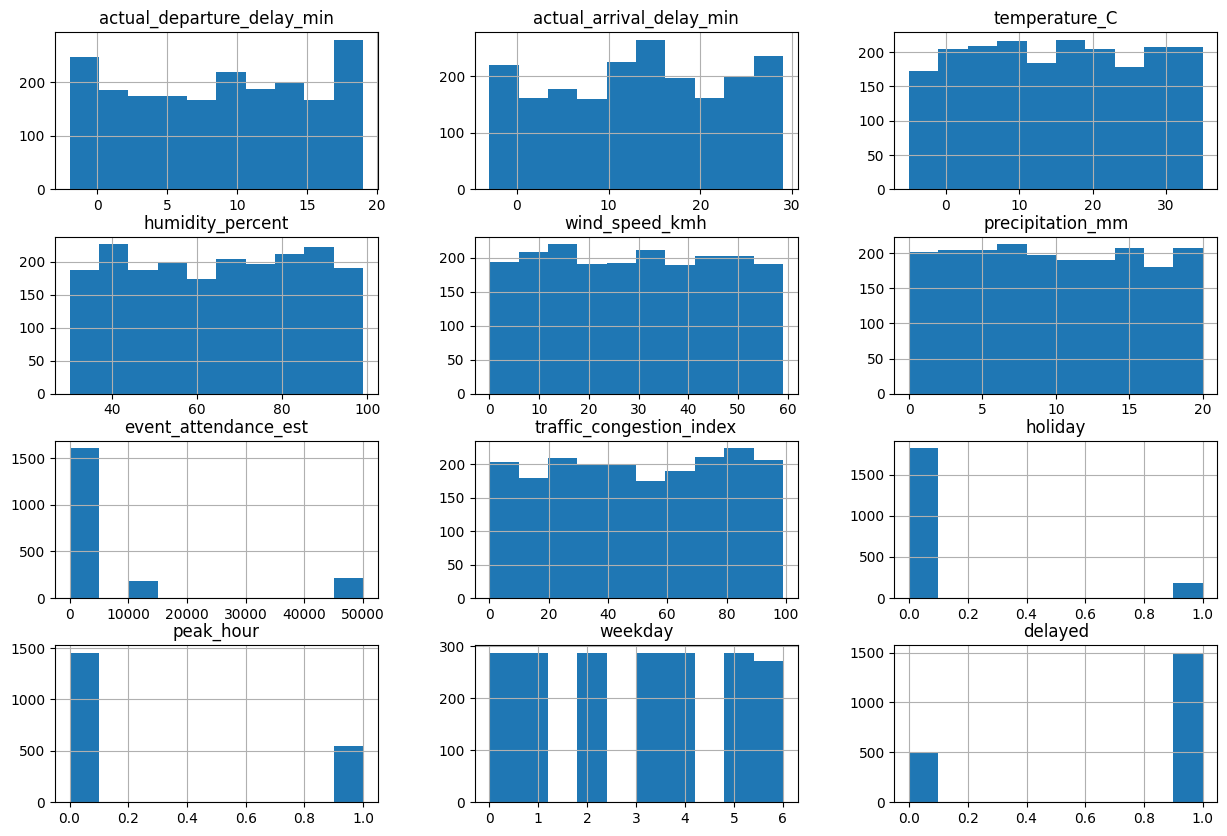

In [ ]:
data.hist(figsize=(15, 10))

In [ ]:
data[data['event_type'].isna()]['event_attendance_est'].value_counts()

,count
event_attendance_est,
0,713
2000,133
50000,121
500,106
10000,100


In [ ]:
data[data['event_type'].notna()]['event_attendance_est'].value_counts()

,count
event_attendance_est,
0,503
50000,89
10000,83
2000,77
500,75


In [ ]:
data['event_type'] = data['event_type'].fillna('Unknown')

In [ ]:
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='delayed', ylabel='count'>

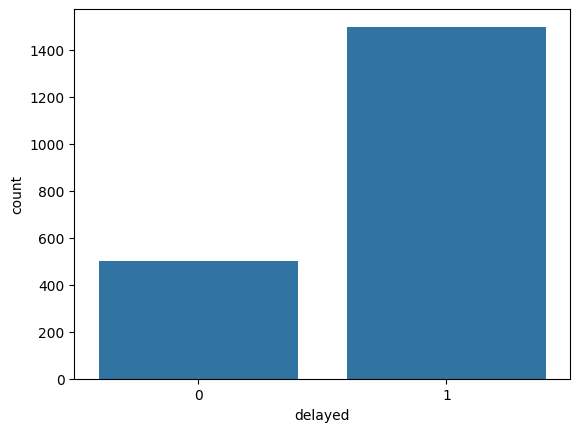

In [ ]:
sns.countplot(x='delayed', data=data)

<Axes: >

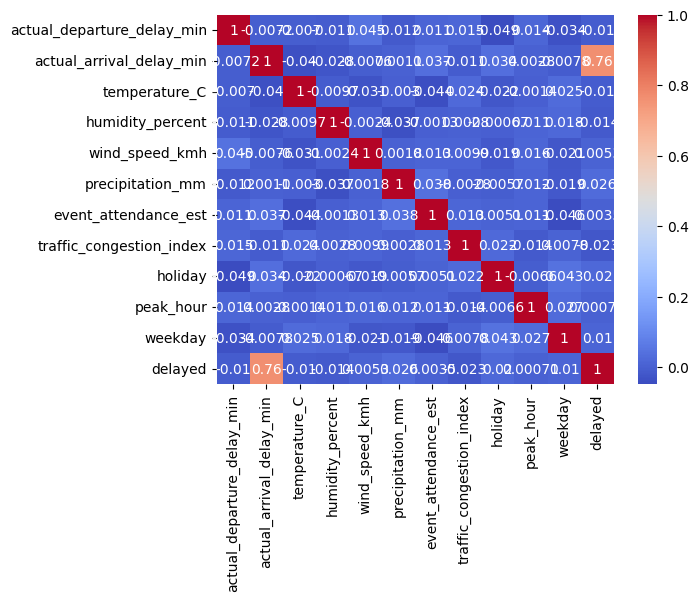

In [ ]:
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

In [ ]:
data['weather_condition'].value_counts()

,count
weather_condition,
Snow,343
Clear,343
Storm,337
Fog,331
Cloudy,325
Rain,321


In [ ]:
data.dtypes

,0
trip_id,object
date,object
time,object
transport_type,object
route_id,object
origin_station,object
destination_station,object
scheduled_departure,object
scheduled_arrival,object
actual_departure_delay_min,int64


In [ ]:
data['trip_id'].nunique()

2000

In [ ]:
data.drop('trip_id',axis=1,inplace=True)


In [ ]:
data.columns

Index(['date', 'time', 'transport_type', 'route_id', 'origin_station',
       'destination_station', 'scheduled_departure', 'scheduled_arrival',
       'actual_departure_delay_min', 'actual_arrival_delay_min',
       'weather_condition', 'temperature_C', 'humidity_percent',
       'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='object')

In [ ]:
# Convert 'date' and 'time' to datetime objects
data['date'] = pd.to_datetime(data['date'])
data['time'] = pd.to_datetime(data['time'], format='%H:%M:%S').dt.time

# Convert 'scheduled_departure' and 'scheduled_arrival' to datetime objects
data['scheduled_departure'] = pd.to_datetime(data['scheduled_departure'])
data['scheduled_arrival'] = pd.to_datetime(data['scheduled_arrival'])

display(data[['date', 'time', 'scheduled_departure', 'scheduled_arrival']].head())

/tmp/ipykernel_436/1153935562.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['scheduled_departure'] = pd.to_datetime(data['scheduled_departure'])
/tmp/ipykernel_436/1153935562.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['scheduled_arrival'] = pd.to_datetime(data['scheduled_arrival'])


,date,time,scheduled_departure,scheduled_arrival
0,2023-01-01,05:00:00,2026-07-13 05:02:00,2026-07-13 05:55:00
1,2023-01-01,05:15:00,2026-07-13 05:16:00,2026-07-13 05:55:00
2,2023-01-01,05:30:00,2026-07-13 05:33:00,2026-07-13 06:17:00
3,2023-01-01,05:45:00,2026-07-13 05:49:00,2026-07-13 06:08:00
4,2023-01-01,06:00:00,2026-07-13 06:00:00,2026-07-13 06:35:00


In [ ]:
# Extract numerical features from 'date' and 'scheduled_departure'
data['day_of_week'] = data['date'].dt.dayofweek
data['month'] = data['date'].dt.month
data['year'] = data['date'].dt.year

data['departure_hour'] = data['scheduled_departure'].dt.hour
data['departure_minute'] = data['scheduled_departure'].dt.minute

data['arrival_hour'] = data['scheduled_arrival'].dt.hour
data['arrival_minute'] = data['scheduled_arrival'].dt.minute

# Calculate scheduled trip duration in minutes
data['scheduled_trip_duration_min'] = (data['scheduled_arrival'] - data['scheduled_departure']).dt.total_seconds() / 60

display(data[['day_of_week', 'month', 'year', 'departure_hour', 'departure_minute', 'arrival_hour', 'arrival_minute', 'scheduled_trip_duration_min']].head())

,day_of_week,month,year,departure_hour,departure_minute,arrival_hour,arrival_minute,scheduled_trip_duration_min
0,6,1,2023,5,2,5,55,53.0
1,6,1,2023,5,16,5,55,39.0
2,6,1,2023,5,33,6,17,44.0
3,6,1,2023,5,49,6,8,19.0
4,6,1,2023,6,0,6,35,35.0


In [ ]:
# Drop original 'date', 'time', 'scheduled_departure', and 'scheduled_arrival' columns
data.drop(columns=['date', 'time', 'scheduled_departure', 'scheduled_arrival'], inplace=True)

display(data.head())

,transport_type,route_id,origin_station,destination_station,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,...,season,delayed,day_of_week,month,year,departure_hour,departure_minute,arrival_hour,arrival_minute,scheduled_trip_duration_min
0,Tram,Route_15,Station_31,Station_6,12,3,Storm,5.1,52,46,...,Winter,0,6,1,2023,5,2,5,55,53.0
1,Metro,Route_12,Station_49,Station_32,15,9,Rain,34.0,64,11,...,Autumn,1,6,1,2023,5,16,5,55,39.0
2,Bus,Route_16,Station_29,Station_42,0,0,Clear,29.5,35,31,...,Autumn,0,6,1,2023,5,33,6,17,44.0
3,Tram,Route_19,Station_26,Station_18,15,10,Clear,27.4,55,41,...,Winter,1,6,1,2023,5,49,6,8,19.0
4,Tram,Route_8,Station_18,Station_15,-1,14,Snow,0.1,90,30,...,Spring,1,6,1,2023,6,0,6,35,35.0


In [ ]:
data.dtypes

,0
transport_type,object
route_id,object
origin_station,object
destination_station,object
actual_departure_delay_min,int64
actual_arrival_delay_min,int64
weather_condition,object
temperature_C,float64
humidity_percent,int64
wind_speed_kmh,int64


##EDA

In [ ]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['actual_departure_delay_min', 'actual_arrival_delay_min',
       'temperature_C', 'humidity_percent', 'wind_speed_kmh',
       'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index',
       'holiday', 'peak_hour', 'weekday', 'delayed',
       'scheduled_trip_duration_min'],
      dtype='object')


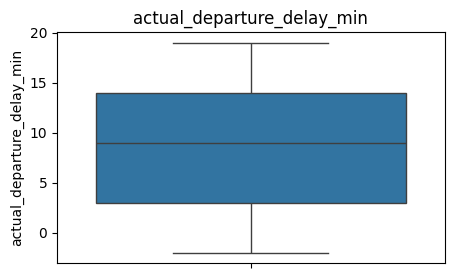

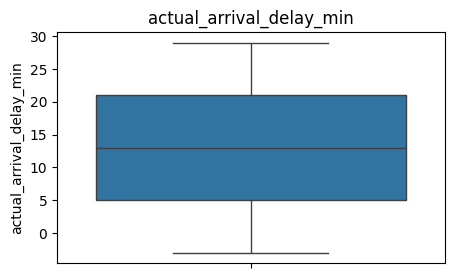

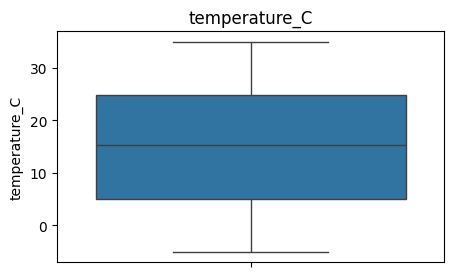

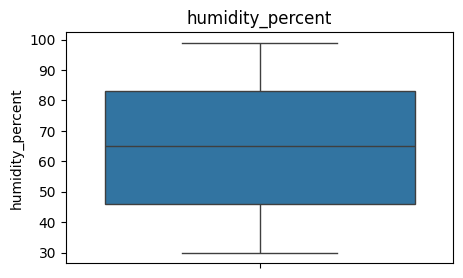

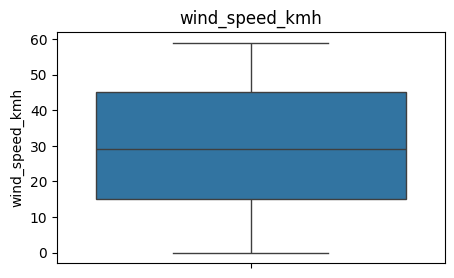

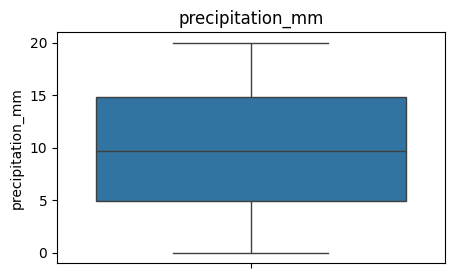

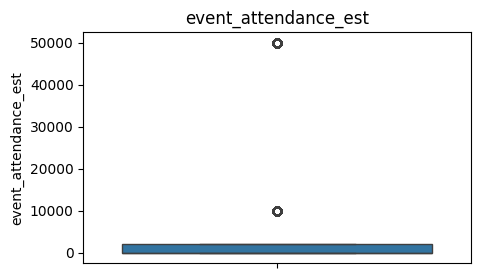

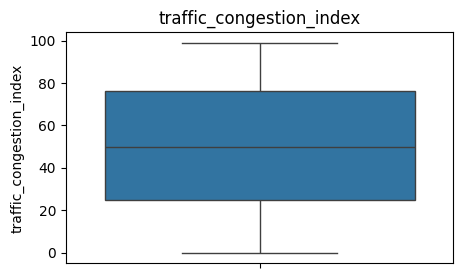

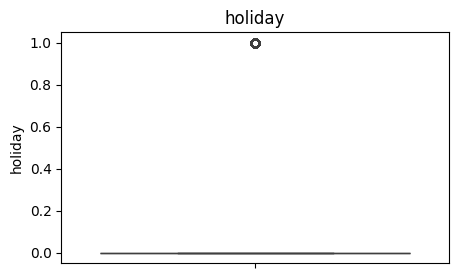

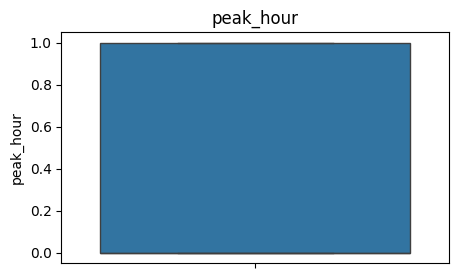

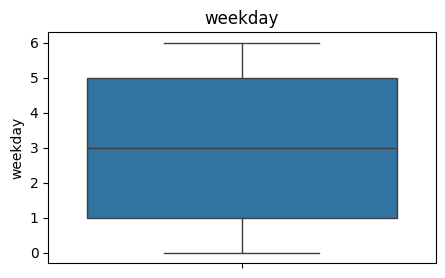

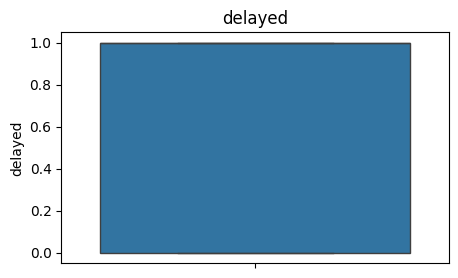

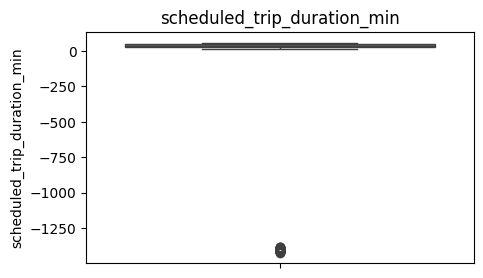

In [ ]:
for col in num_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=data[col])
    plt.title(col)
    plt.show()

In [ ]:
data['scheduled_trip_duration_min'].describe()

,scheduled_trip_duration_min
count,2000.000000
mean,4.603500
std,213.411993
min,-1422.000000
25%,27.000000
50%,36.000000
75%,46.000000
max,59.000000


In [ ]:
data.nsmallest(5, 'scheduled_trip_duration_min')

,transport_type,route_id,origin_station,destination_station,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,...,season,delayed,day_of_week,month,year,departure_hour,departure_minute,arrival_hour,arrival_minute,scheduled_trip_duration_min
1611,Train,Route_17,Station_18,Station_44,16,10,Cloudy,18.4,59,43,...,Winter,1,1,1,2023,23,47,0,5,-1422.0
1131,Train,Route_9,Station_28,Station_18,3,10,Fog,28.5,85,22,...,Summer,1,3,1,2023,23,48,0,10,-1418.0
363,Train,Route_18,Station_2,Station_5,0,8,Cloudy,19.7,71,47,...,Winter,1,2,1,2023,23,46,0,9,-1417.0
1035,Train,Route_8,Station_49,Station_45,14,10,Storm,5.3,75,47,...,Summer,1,2,1,2023,23,49,0,12,-1417.0
1707,Train,Route_1,Station_13,Station_12,6,19,Cloudy,10.6,69,10,...,Summer,1,2,1,2023,23,45,0,8,-1417.0


In [ ]:
data.loc[data['scheduled_trip_duration_min'] < 0,
         'scheduled_trip_duration_min'] += 24 * 60

In [ ]:
data['scheduled_trip_duration_min'].describe()

,scheduled_trip_duration_min
count,2000.000000
mean,37.003500
std,11.341243
min,16.000000
25%,27.000000
50%,37.000000
75%,47.000000
max,59.000000


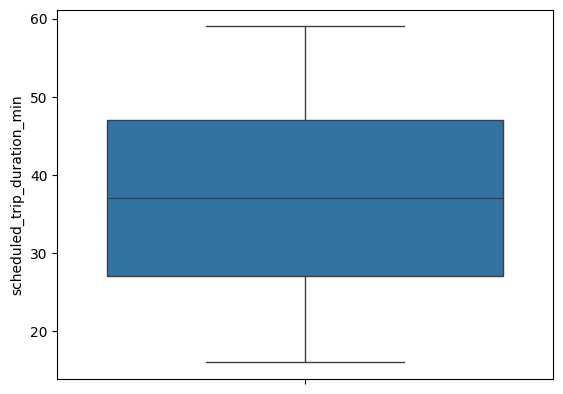

In [ ]:
sns.boxplot(y=data['scheduled_trip_duration_min'])
plt.show()

In [ ]:
data['transport_type'].nunique()

4

In [ ]:
data = pd.get_dummies(data, columns=['transport_type'], dtype=int)
data.head()

,route_id,origin_station,destination_station,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,...,year,departure_hour,departure_minute,arrival_hour,arrival_minute,scheduled_trip_duration_min,transport_type_Bus,transport_type_Metro,transport_type_Train,transport_type_Tram
0,Route_15,Station_31,Station_6,12,3,Storm,5.1,52,46,13.0,...,2023,5,2,5,55,53.0,0,0,0,1
1,Route_12,Station_49,Station_32,15,9,Rain,34.0,64,11,11.4,...,2023,5,16,5,55,39.0,0,1,0,0
2,Route_16,Station_29,Station_42,0,0,Clear,29.5,35,31,14.1,...,2023,5,33,6,17,44.0,1,0,0,0
3,Route_19,Station_26,Station_18,15,10,Clear,27.4,55,41,6.4,...,2023,5,49,6,8,19.0,0,0,0,1
4,Route_8,Station_18,Station_15,-1,14,Snow,0.1,90,30,18.5,...,2023,6,0,6,35,35.0,0,0,0,1


In [ ]:
data['route_id'].nunique()

20

In [ ]:
data = pd.get_dummies(data, columns=['route_id'], dtype=int)
display(data.head())

,origin_station,destination_station,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,...,route_id_Route_19,route_id_Route_2,route_id_Route_20,route_id_Route_3,route_id_Route_4,route_id_Route_5,route_id_Route_6,route_id_Route_7,route_id_Route_8,route_id_Route_9
0,Station_31,Station_6,12,3,Storm,5.1,52,46,13.0,Unknown,...,0,0,0,0,0,0,0,0,0,0
1,Station_49,Station_32,15,9,Rain,34.0,64,11,11.4,Unknown,...,0,0,0,0,0,0,0,0,0,0
2,Station_29,Station_42,0,0,Clear,29.5,35,31,14.1,Sports,...,0,0,0,0,0,0,0,0,0,0
3,Station_26,Station_18,15,10,Clear,27.4,55,41,6.4,Unknown,...,1,0,0,0,0,0,0,0,0,0
4,Station_18,Station_15,-1,14,Snow,0.1,90,30,18.5,Unknown,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
data['origin_station'].nunique()

50

In [ ]:
data = pd.get_dummies(data, columns=['origin_station'], dtype=int)
display(data.head())

,destination_station,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,...,origin_station_Station_46,origin_station_Station_47,origin_station_Station_48,origin_station_Station_49,origin_station_Station_5,origin_station_Station_50,origin_station_Station_6,origin_station_Station_7,origin_station_Station_8,origin_station_Station_9
0,Station_6,12,3,Storm,5.1,52,46,13.0,Unknown,500,...,0,0,0,0,0,0,0,0,0,0
1,Station_32,15,9,Rain,34.0,64,11,11.4,Unknown,0,...,0,0,0,1,0,0,0,0,0,0
2,Station_42,0,0,Clear,29.5,35,31,14.1,Sports,0,...,0,0,0,0,0,0,0,0,0,0
3,Station_18,15,10,Clear,27.4,55,41,6.4,Unknown,500,...,0,0,0,0,0,0,0,0,0,0
4,Station_15,-1,14,Snow,0.1,90,30,18.5,Unknown,500,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data['destination_station'].nunique()

50

In [ ]:
data = pd.get_dummies(data, columns=['destination_station'], dtype=int)
display(data.head())

,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,...,destination_station_Station_46,destination_station_Station_47,destination_station_Station_48,destination_station_Station_49,destination_station_Station_5,destination_station_Station_50,destination_station_Station_6,destination_station_Station_7,destination_station_Station_8,destination_station_Station_9
0,12,3,Storm,5.1,52,46,13.0,Unknown,500,81,...,0,0,0,0,0,0,1,0,0,0
1,15,9,Rain,34.0,64,11,11.4,Unknown,0,53,...,0,0,0,0,0,0,0,0,0,0
2,0,0,Clear,29.5,35,31,14.1,Sports,0,67,...,0,0,0,0,0,0,0,0,0,0
3,15,10,Clear,27.4,55,41,6.4,Unknown,500,84,...,0,0,0,0,0,0,0,0,0,0
4,-1,14,Snow,0.1,90,30,18.5,Unknown,500,46,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data['weather_condition'].nunique()

6

In [ ]:
data = pd.get_dummies(data, columns=['weather_condition'], dtype=int)
display(data.head())

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,...,destination_station_Station_6,destination_station_Station_7,destination_station_Station_8,destination_station_Station_9,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Fog,weather_condition_Rain,weather_condition_Snow,weather_condition_Storm
0,12,3,5.1,52,46,13.0,Unknown,500,81,0,...,1,0,0,0,0,0,0,0,0,1
1,15,9,34.0,64,11,11.4,Unknown,0,53,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,29.5,35,31,14.1,Sports,0,67,1,...,0,0,0,0,1,0,0,0,0,0
3,15,10,27.4,55,41,6.4,Unknown,500,84,0,...,0,0,0,0,1,0,0,0,0,0
4,-1,14,0.1,90,30,18.5,Unknown,500,46,0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
data['event_type'].nunique()

6

In [ ]:
data = pd.get_dummies(data, columns=['event_type'], dtype=int)
display(data.head())

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,...,weather_condition_Fog,weather_condition_Rain,weather_condition_Snow,weather_condition_Storm,event_type_Concert,event_type_Festival,event_type_Parade,event_type_Protest,event_type_Sports,event_type_Unknown
0,12,3,5.1,52,46,13.0,500,81,0,1,...,0,0,0,1,0,0,0,0,0,1
1,15,9,34.0,64,11,11.4,0,53,0,0,...,0,1,0,0,0,0,0,0,0,1
2,0,0,29.5,35,31,14.1,0,67,1,0,...,0,0,0,0,0,0,0,0,1,0
3,15,10,27.4,55,41,6.4,500,84,0,0,...,0,0,0,0,0,0,0,0,0,1
4,-1,14,0.1,90,30,18.5,500,46,0,0,...,0,0,1,0,0,0,0,0,0,1


In [ ]:
data['season'].nunique()

4

In [ ]:
data = pd.get_dummies(data, columns=['season'], dtype=int)
display(data.head())

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,...,event_type_Concert,event_type_Festival,event_type_Parade,event_type_Protest,event_type_Sports,event_type_Unknown,season_Autumn,season_Spring,season_Summer,season_Winter
0,12,3,5.1,52,46,13.0,500,81,0,1,...,0,0,0,0,0,1,0,0,0,1
1,15,9,34.0,64,11,11.4,0,53,0,0,...,0,0,0,0,0,1,1,0,0,0
2,0,0,29.5,35,31,14.1,0,67,1,0,...,0,0,0,0,1,0,1,0,0,0
3,15,10,27.4,55,41,6.4,500,84,0,0,...,0,0,0,0,0,1,0,0,0,1
4,-1,14,0.1,90,30,18.5,500,46,0,0,...,0,0,0,0,0,1,0,1,0,0


In [ ]:
data.shape

(2000, 160)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 160 entries, actual_departure_delay_min to season_Winter
dtypes: float64(3), int32(7), int64(150)
memory usage: 2.4 MB


### Data Splitting

In [ ]:
print(X.columns.tolist())

['temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index', 'holiday', 'peak_hour', 'weekday', 'day_of_week', 'month', 'year', 'departure_hour', 'departure_minute', 'arrival_hour', 'arrival_minute', 'scheduled_trip_duration_min', 'transport_type_Bus', 'transport_type_Metro', 'transport_type_Train', 'transport_type_Tram', 'route_id_Route_1', 'route_id_Route_10', 'route_id_Route_11', 'route_id_Route_12', 'route_id_Route_13', 'route_id_Route_14', 'route_id_Route_15', 'route_id_Route_16', 'route_id_Route_17', 'route_id_Route_18', 'route_id_Route_19', 'route_id_Route_2', 'route_id_Route_20', 'route_id_Route_3', 'route_id_Route_4', 'route_id_Route_5', 'route_id_Route_6', 'route_id_Route_7', 'route_id_Route_8', 'route_id_Route_9', 'origin_station_Station_1', 'origin_station_Station_10', 'origin_station_Station_11', 'origin_station_Station_12', 'origin_station_Station_13', 'origin_station_Station_14', 'origin_station_Station_1

In [ ]:
from sklearn.model_selection import train_test_split
X = data.drop(['delayed','actual_departure_delay_min','actual_arrival_delay_min'], axis=1)
y = data['delayed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(random_state=42, solver='liblinear',class_weight='balanced') # 'liblinear' solver works well for small datasets and handles L1/L2 regularization
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Display classification report for more detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5200
Precision: 0.7143
Recall: 0.6000
F1-Score: 0.6522

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.28      0.23       100
           1       0.71      0.60      0.65       300

    accuracy                           0.52       400
   macro avg       0.45      0.44      0.44       400
weighted avg       0.58      0.52      0.55       400


Confusion Matrix:
[[ 28  72]
 [120 180]]


### Model Training: RandomForestClassifier


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
print("RandomForestClassifier model trained successfully!")

RandomForestClassifier model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"RandomForestClassifier Accuracy: {accuracy_rf:.4f}")
print(f"RandomForestClassifier Precision: {precision_rf:.4f}")
print(f"RandomForestClassifier Recall: {recall_rf:.4f}")
print(f"RandomForestClassifier F1-Score: {f1_rf:.4f}")

# Display classification report for Random Forest
print("\nRandomForestClassifier Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Display confusion matrix for Random Forest
print("\nRandomForestClassifier Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

RandomForestClassifier Accuracy: 0.7500
RandomForestClassifier Precision: 0.7500
RandomForestClassifier Recall: 1.0000
RandomForestClassifier F1-Score: 0.8571

RandomForestClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.75      1.00      0.86       300

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.56      0.75      0.64       400


RandomForestClassifier Confusion Matrix:
[[  0 100]
 [  0 300]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Model Training: Decision Tree Classifier


In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Train the model on the training data
dt_model.fit(X_train, y_train)

print("Decision Tree Classifier model trained successfully!")

Decision Tree Classifier model trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set using the Decision Tree model
y_pred_dt = dt_model.predict(X_test)

# Calculate evaluation metrics for Decision Tree
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Classifier Precision: {precision_dt:.4f}")
print(f"Decision Tree Classifier Recall: {recall_dt:.4f}")
print(f"Decision Tree Classifier F1-Score: {f1_dt:.4f}")

# Display classification report for Decision Tree
print("\nDecision Tree Classifier Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Display confusion matrix for Decision Tree
print("\nDecision Tree Classifier Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Classifier Accuracy: 0.6275
Decision Tree Classifier Precision: 0.7525
Decision Tree Classifier Recall: 0.7500
Decision Tree Classifier F1-Score: 0.7513

Decision Tree Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.26      0.26      0.26       100
           1       0.75      0.75      0.75       300

    accuracy                           0.63       400
   macro avg       0.50      0.51      0.50       400
weighted avg       0.63      0.63      0.63       400


Decision Tree Classifier Confusion Matrix:
[[ 26  74]
 [ 75 225]]


In [ ]:
data['delayed'].value_counts()

,count
delayed,
1,1499
0,501


KNN

In [ ]:
#KNN
#finding the optimum k value

from sklearn.neighbors import KNeighborsClassifier
acc_score=[]
for k in range(3,10):
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  y_pred_knn=knn.predict(X_test)
  acc=accuracy_score(y_test,y_pred_knn)
  acc_score.append(acc)

acc_score

[0.6475, 0.6225, 0.6775, 0.66, 0.6975, 0.675, 0.705]

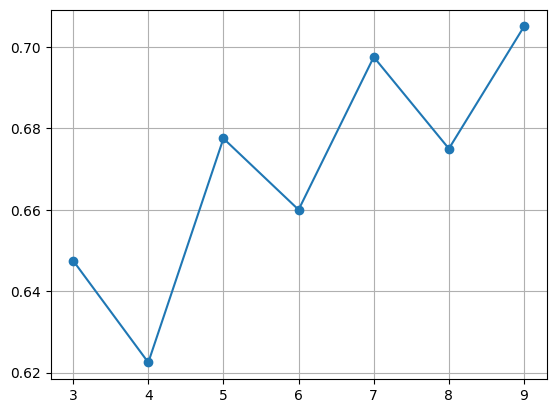

In [ ]:
plt.plot(np.arange(3,10),acc_score,'o-')
plt.grid()

In [ ]:
#optimum k value is 9 ( ACC HIGHEST)
#Train KNN model for k=9
knn=KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train,y_train)
y_pred_knn=knn.predict(X_test)
print(confusion_matrix(y_test,y_pred_knn))
print(accuracy_score(y_test,y_pred_knn))
print(recall_score(y_test,y_pred_knn))
print(f1_score(y_test,y_pred_knn))
print(precision_score(y_test,y_pred_knn))


[[  2  98]
 [ 20 280]]
0.705
0.9333333333333333
0.8259587020648967
0.7407407407407407


In [ ]:
X.describe()

,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,day_of_week,...,event_type_Concert,event_type_Festival,event_type_Parade,event_type_Protest,event_type_Sports,event_type_Unknown,season_Autumn,season_Spring,season_Summer,season_Winter
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,2.976000,...,0.101500,0.11050,0.052500,0.043000,0.106000,0.586500,0.24000,0.251000,0.262000,0.247000
std,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,1.990328,...,0.302065,0.31359,0.223089,0.202908,0.307915,0.492584,0.42719,0.433697,0.439833,0.431375
min,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,3.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000
75%,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,5.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.00000,1.000000,1.000000,0.000000
max,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,6.000000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify continuous numerical columns for scaling
# These columns were previously identified as requiring scaling
numerical_cols_to_scale = [
    'temperature_C',
    'humidity_percent',
    'wind_speed_kmh',
    'precipitation_mm',
    'event_attendance_est',
    'traffic_congestion_index',
    'scheduled_trip_duration_min'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data for the numerical columns
X_train[numerical_cols_to_scale] = scaler.fit_transform(X_train[numerical_cols_to_scale])

# Transform the test data using the *same* fitted scaler
X_test[numerical_cols_to_scale] = scaler.transform(X_test[numerical_cols_to_scale])

print("X_train and X_test numerical features scaled successfully!")
display(X_train.head())

X_train and X_test numerical features scaled successfully!


,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,day_of_week,...,event_type_Concert,event_type_Festival,event_type_Parade,event_type_Protest,event_type_Sports,event_type_Unknown,season_Autumn,season_Spring,season_Summer,season_Winter
760,1.002868,-1.213025,-0.443770,-0.436638,-0.426391,0.189668,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
1498,-1.265714,0.406755,-0.154528,1.098034,-0.426391,0.224145,1,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1147,1.167384,-0.280424,1.465230,-0.281446,-0.426391,0.534440,0,0,4,4,...,0,0,0,0,0,1,0,1,0,0
1101,-0.018860,-0.378593,-1.716437,1.684313,-0.426391,0.499963,0,1,3,3,...,1,0,0,0,0,0,1,0,0,0
1550,-1.672674,0.750345,-1.485043,-0.557342,-0.393813,1.430849,0,0,1,1,...,1,0,0,0,0,0,1,0,0,0


In [ ]:
knn_scaled=KNeighborsClassifier(n_neighbors=9)
knn_scaled.fit(X_train,y_train)
y_pred_knn=knn_scaled.predict(X_test)
print(confusion_matrix(y_test,y_pred_knn))
print(accuracy_score(y_test,y_pred_knn))
print(recall_score(y_test,y_pred_knn))
print(f1_score(y_test,y_pred_knn))
print(precision_score(y_test,y_pred_knn))

[[  5  95]
 [ 13 287]]
0.73
0.9566666666666667
0.841642228739003
0.7513089005235603


In [ ]:
#SVM
from sklearn.svm import SVC

In [ ]:
#linear
svmclf_linear=SVC(kernel='linear')
svmclf_linear.fit(X_train,y_train)
y_pred_svmclf_linear=svmclf_linear.predict(X_test)
print(confusion_matrix(y_test,y_pred_svmclf_linear))
print(accuracy_score(y_test,y_pred_svmclf_linear))
print(recall_score(y_test,y_pred_svmclf_linear))
print(f1_score(y_test,y_pred_svmclf_linear))
print(precision_score(y_test,y_pred_svmclf_linear))

[[  2  98]
 [ 16 284]]
0.715
0.9466666666666667
0.8328445747800587
0.743455497382199


In [ ]:
#Poly
svmclf_poly=SVC(kernel='poly')
svmclf_poly.fit(X_train,y_train)
y_pred_svmclf_poly=svmclf_poly.predict(X_test)
print(confusion_matrix(y_test,y_pred_svmclf_poly))
print(accuracy_score(y_test,y_pred_svmclf_poly))
print(recall_score(y_test,y_pred_svmclf_poly))
print(f1_score(y_test,y_pred_svmclf_poly))
print(precision_score(y_test,y_pred_svmclf_poly))


[[  0 100]
 [  0 300]]
0.75
1.0
0.8571428571428571
0.75


In [ ]:
#rbf
svmclf_rbf=SVC(kernel='rbf')
svmclf_rbf.fit(X_train,y_train)
y_pred_svmclf_rbf=svmclf_rbf.predict(X_test)
print(confusion_matrix(y_test,y_pred_svmclf_rbf))
print(accuracy_score(y_test,y_pred_svmclf_rbf))
print(recall_score(y_test,y_pred_svmclf_rbf))
print(f1_score(y_test,y_pred_svmclf_rbf))
print(precision_score(y_test,y_pred_svmclf_rbf))


[[  0 100]
 [  0 300]]
0.75
1.0
0.8571428571428571
0.75


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get metrics for Logistic Regression (already in variables: accuracy, precision, recall, f1)
logistic_regression_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

# Get metrics for Random Forest (already in variables: accuracy_rf, precision_rf, recall_rf, f1_rf)
random_forest_metrics = {
    'Accuracy': accuracy_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1-Score': f1_rf
}

# Get metrics for Decision Tree (already in variables: accuracy_dt, precision_dt, recall_dt, f1_dt)
decision_tree_metrics = {
    'Accuracy': accuracy_dt,
    'Precision': precision_dt,
    'Recall': recall_dt,
    'F1-Score': f1_dt
}

# Metrics for KNN (k=9, Scaled) from cell pc2d23dpdHhJ
y_pred_knn_scaled = knn_scaled.predict(X_test)
knn_scaled_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_knn_scaled),
    'Precision': precision_score(y_test, y_pred_knn_scaled),
    'Recall': recall_score(y_test, y_pred_knn_scaled),
    'F1-Score': f1_score(y_test, y_pred_knn_scaled)
}

# Metrics for SVM Linear from cell rBDSWw_LgRr_
y_pred_svmclf_linear = svmclf_linear.predict(X_test)
svm_linear_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svmclf_linear),
    'Precision': precision_score(y_test, y_pred_svmclf_linear),
    'Recall': recall_score(y_test, y_pred_svmclf_linear),
    'F1-Score': f1_score(y_test, y_pred_svmclf_linear)
}

# Metrics for SVM Poly from cell p34mOJfPgY6y
y_pred_svmclf_poly = svmclf_poly.predict(X_test)
svm_poly_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svmclf_poly),
    'Precision': precision_score(y_test, y_pred_svmclf_poly),
    'Recall': recall_score(y_test, y_pred_svmclf_poly),
    'F1-Score': f1_score(y_test, y_pred_svmclf_poly)
}

# Metrics for SVM RBF from cell WmsbaJo8geTE
y_pred_svmclf_rbf = svmclf_rbf.predict(X_test)
svm_rbf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svmclf_rbf),
    'Precision': precision_score(y_test, y_pred_svmclf_rbf),
    'Recall': recall_score(y_test, y_pred_svmclf_rbf),
    'F1-Score': f1_score(y_test, y_pred_svmclf_rbf)
}

# Create a dictionary to hold all model results
results = {
    'Logistic Regression': logistic_regression_metrics,
    'Random Forest': random_forest_metrics,
    'Decision Tree': decision_tree_metrics,
    'KNN (k=9, Scaled)': knn_scaled_metrics,
    'SVM - Linear Kernel': svm_linear_metrics,
    'SVM - Poly Kernel': svm_poly_metrics,
    'SVM - RBF Kernel': svm_rbf_metrics
}

# Convert to DataFrame for better presentation
comparison_df = pd.DataFrame.from_dict(results, orient='index')
comparison_df.index.name = 'Model'

display(comparison_df.round(4))

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.5200,0.7143,0.6000,0.6522
Random Forest,0.7500,0.7500,1.0000,0.8571
Decision Tree,0.6275,0.7525,0.7500,0.7513
"KNN (k=9, Scaled)",0.7300,0.7513,0.9567,0.8416
SVM - Linear Kernel,0.7150,0.7435,0.9467,0.8328
SVM - Poly Kernel,0.7500,0.7500,1.0000,0.8571
SVM - RBF Kernel,0.7500,0.7500,1.0000,0.8571


Selecting Random Forest as the classification model

###Feature Importance Analysis (Random Forest)

/tmp/ipykernel_436/917706413.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='magma')


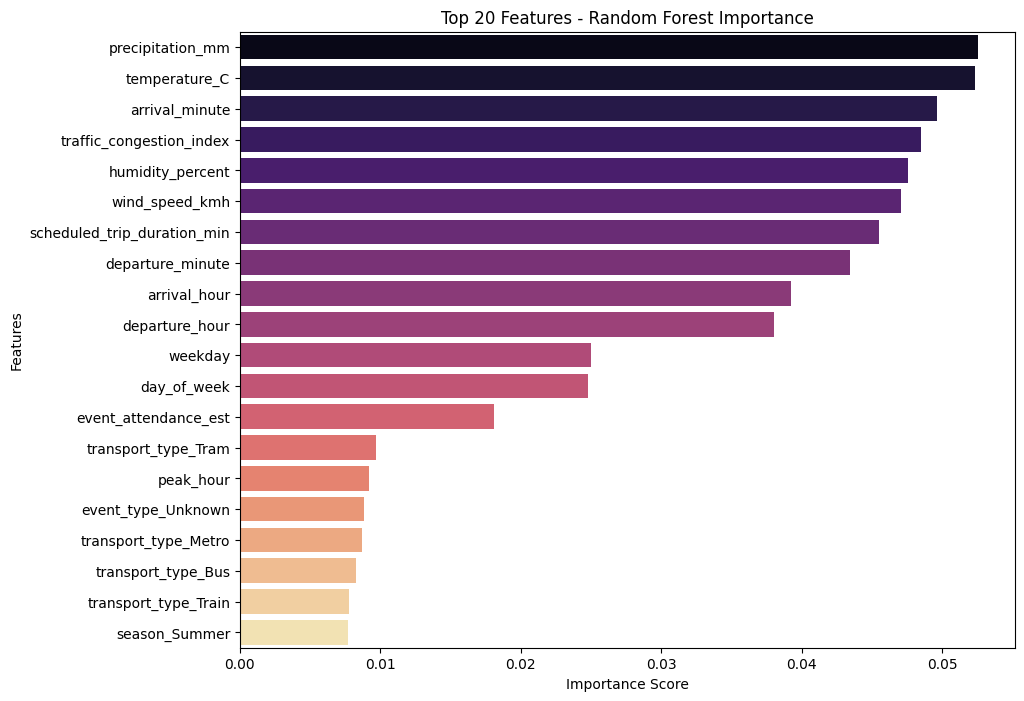

,Feature,Importance
3,precipitation_mm,0.052563
0,temperature_C,0.052350
15,arrival_minute,0.049651
5,traffic_congestion_index,0.048532
1,humidity_percent,0.047604
2,wind_speed_kmh,0.047053
16,scheduled_trip_duration_min,0.045483
13,departure_minute,0.043466
14,arrival_hour,0.039239
12,departure_hour,0.038044


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='magma')
plt.title('Top 20 Features - Random Forest Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Display the top 10 as a table
display(feature_importance_df.head(10))